# Calidad de datos

## Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import ast


### Variables globales de conexión

In [7]:
DB_NAME = "openbeauty"
DB_PATH = f"../data/{DB_NAME}.db"
TABLE_NAME = "raw_products"

conn = sqlite3.connect(DB_PATH)


Objetivo: Responder que tan util es esta data ?
* Unicidad
* Concistencia
* Inconsistencia 

In [8]:
df_raw_products = pd.read_sql("SELECT * FROM raw_products", conn)

In [9]:
df_raw_products.head()

,_id,code,rev,update_key,brands,product_name,product_type,countries,countries_tags,countries_hierarchy,...,created_t,last_modified_t,last_updated_t,creator,last_editor,last_modified_by,data_quality_tags,page,batch_id,dtinserted
0,8410757001090,8410757001090,34,key_1743168287,S'nonas,Crema Manos,beauty,"Morocco, United States, en:france","[""en:france"", ""en:morocco"", ""en:united-states""]","[""en:france"", ""en:morocco"", ""en:united-states""]",...,1731329832,1779248127,1779248127,smoothie-app,agenticcommonsbot,agenticcommonsbot,"[""en:no-packaging-data""]",1,1,2026-05-22 16:05:44.417078
1,6281006408647,6281006408647,30,brands,"Unilever,Vaseline",,beauty,"Germany, Morocco, en:saudi-arabia","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]",...,1731340361,1771266702,1771266702,smoothie-app,scanbot,scanbot,"[""en:no-packaging-data""]",1,1,2026-05-22 16:05:44.417078
2,80466468,80466468,68,brands,"unilever, dove",DOVE Déodorant Femme Anti-Transpirant Stick Or...,beauty,"France, Libya, Morocco, Saudi Arabia, Spain, e...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...",...,1537085263,1779261226,1779261226,openfoodfacts-contributors,agenticcommonsbot,agenticcommonsbot,"[""en:packaging-data-incomplete""]",1,1,2026-05-22 16:05:44.417078
3,3337875598996,3337875598996,33,brands,CeraVe,moisturising cream,beauty,"France,Morocco,Romania","[""en:france"", ""en:morocco"", ""en:romania""]","[""en:france"", ""en:morocco"", ""en:romania""]",...,1730480414,1779263998,1779263998,smoothie-app,agenticcommonsbot,agenticcommonsbot,"[""en:packaging-data-incomplete""]",1,1,2026-05-22 16:05:44.417078
4,3574669909594,3574669909594,35,key_1743168287,Johnson’s baby,,beauty,"Algeria, Morocco, en:ukraine","[""en:algeria"", ""en:morocco"", ""en:ukraine""]","[""en:algeria"", ""en:morocco"", ""en:ukraine""]",...,1660916439,1775820851,1775820851,smoothie-app,foodless,foodless,"[""en:no-packaging-data""]",1,1,2026-05-22 16:05:44.417078


In [10]:
df_raw_products.shape

(50000, 32)

In [11]:
df = df_raw_products

## Data Quality

### Completitud 

In [12]:
df[['countries','countries_tags', 'countries_hierarchy']].isnull().sum()

countries              736
countries_tags         495
countries_hierarchy    736
dtype: int64

Observando que la cantidad de nulos dentro de las variables countries, se verificara sus diferencias para unificarlas

In [13]:
df[['countries','countries_tags', 'countries_hierarchy']].head()

,countries,countries_tags,countries_hierarchy
0,"Morocco, United States, en:france","[""en:france"", ""en:morocco"", ""en:united-states""]","[""en:france"", ""en:morocco"", ""en:united-states""]"
1,"Germany, Morocco, en:saudi-arabia","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]"
2,"France, Libya, Morocco, Saudi Arabia, Spain, e...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo..."
3,"France,Morocco,Romania","[""en:france"", ""en:morocco"", ""en:romania""]","[""en:france"", ""en:morocco"", ""en:romania""]"
4,"Algeria, Morocco, en:ukraine","[""en:algeria"", ""en:morocco"", ""en:ukraine""]","[""en:algeria"", ""en:morocco"", ""en:ukraine""]"


In [14]:
df[['categories', 'categories_hierarchy']].head()

,categories,categories_hierarchy
0,"Creams,Non-food-products,Open-beauty-facts","[""en:Creams"", ""en:Non-food-products"", ""en:Open..."
1,"Incorrect product type,Non-food-products,Open-...","[""en:incorrect-product-type"", ""en:Non-food-pro..."
2,"Déodorants anti-transpirants, en:open-beauty-f...","[""en:D\u00e9odorants anti-transpirants"", ""en:o..."
3,fr:baume hydratant,"[""fr:baume hydratant""]"
4,,[]


In [15]:
df[['categories','categories_hierarchy']].isnull().sum()

categories              18086
categories_hierarchy    18056
dtype: int64

#### Unificando variables que son "iguales"

In [16]:
df['canonical_countries'] = df['countries_hierarchy'].combine_first(df['countries_tags']).combine_first(df['countries'])

In [17]:
df['canonical_categories'] = df['categories_hierarchy'].combine_first(df['categories'])

In [18]:
df.columns

Index(['_id', 'code', 'rev', 'update_key', 'brands', 'product_name',
       'product_type', 'countries', 'countries_tags', 'countries_hierarchy',
       'categories_hierarchy', 'categories', 'product_quantity',
       'product_quantity_unit', 'quantity', 'ingredients_n',
       'known_ingredients_n', 'unknown_ingredients_n', 'completeness',
       'scans_n', 'unique_scans_n', 'popularity_tags', 'created_t',
       'last_modified_t', 'last_updated_t', 'creator', 'last_editor',
       'last_modified_by', 'data_quality_tags', 'page', 'batch_id',
       'dtinserted', 'canonical_countries', 'canonical_categories'],
      dtype='str')

### Umbral de Tolerancia

Definiendo las columnas que determinan la calidad de los datos

In [19]:
quality_columns = [
    "code",
    "product_name",
    "product_type",
    "brands",
    "canonical_categories",
    "canonical_countries",
    "ingredients_n"
]

Definiendo las columnas criticas que determinan la calidad 

In [20]:
critical_columns = [
    "product_name",
    "brands",
    "canonical_categories",
    "canonical_countries"
]

In [21]:
df['completeness_ratio'] = df[quality_columns].notna().mean(axis=1)

In [22]:
df['compl_critical_ratio'] = df[critical_columns].notna().mean(axis=1)

In [23]:
df.columns

Index(['_id', 'code', 'rev', 'update_key', 'brands', 'product_name',
       'product_type', 'countries', 'countries_tags', 'countries_hierarchy',
       'categories_hierarchy', 'categories', 'product_quantity',
       'product_quantity_unit', 'quantity', 'ingredients_n',
       'known_ingredients_n', 'unknown_ingredients_n', 'completeness',
       'scans_n', 'unique_scans_n', 'popularity_tags', 'created_t',
       'last_modified_t', 'last_updated_t', 'creator', 'last_editor',
       'last_modified_by', 'data_quality_tags', 'page', 'batch_id',
       'dtinserted', 'canonical_countries', 'canonical_categories',
       'completeness_ratio', 'compl_critical_ratio'],
      dtype='str')

In [24]:
df.head()

,_id,code,rev,update_key,brands,product_name,product_type,countries,countries_tags,countries_hierarchy,...,last_editor,last_modified_by,data_quality_tags,page,batch_id,dtinserted,canonical_countries,canonical_categories,completeness_ratio,compl_critical_ratio
0,8410757001090,8410757001090,34,key_1743168287,S'nonas,Crema Manos,beauty,"Morocco, United States, en:france","[""en:france"", ""en:morocco"", ""en:united-states""]","[""en:france"", ""en:morocco"", ""en:united-states""]",...,agenticcommonsbot,agenticcommonsbot,"[""en:no-packaging-data""]",1,1,2026-05-22 16:05:44.417078,"[""en:france"", ""en:morocco"", ""en:united-states""]","[""en:Creams"", ""en:Non-food-products"", ""en:Open...",1.0,1.0
1,6281006408647,6281006408647,30,brands,"Unilever,Vaseline",,beauty,"Germany, Morocco, en:saudi-arabia","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]",...,scanbot,scanbot,"[""en:no-packaging-data""]",1,1,2026-05-22 16:05:44.417078,"[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]","[""en:incorrect-product-type"", ""en:Non-food-pro...",1.0,1.0
2,80466468,80466468,68,brands,"unilever, dove",DOVE Déodorant Femme Anti-Transpirant Stick Or...,beauty,"France, Libya, Morocco, Saudi Arabia, Spain, e...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...",...,agenticcommonsbot,agenticcommonsbot,"[""en:packaging-data-incomplete""]",1,1,2026-05-22 16:05:44.417078,"[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...","[""en:D\u00e9odorants anti-transpirants"", ""en:o...",1.0,1.0
3,3337875598996,3337875598996,33,brands,CeraVe,moisturising cream,beauty,"France,Morocco,Romania","[""en:france"", ""en:morocco"", ""en:romania""]","[""en:france"", ""en:morocco"", ""en:romania""]",...,agenticcommonsbot,agenticcommonsbot,"[""en:packaging-data-incomplete""]",1,1,2026-05-22 16:05:44.417078,"[""en:france"", ""en:morocco"", ""en:romania""]","[""fr:baume hydratant""]",1.0,1.0
4,3574669909594,3574669909594,35,key_1743168287,Johnson’s baby,,beauty,"Algeria, Morocco, en:ukraine","[""en:algeria"", ""en:morocco"", ""en:ukraine""]","[""en:algeria"", ""en:morocco"", ""en:ukraine""]",...,foodless,foodless,"[""en:no-packaging-data""]",1,1,2026-05-22 16:05:44.417078,"[""en:algeria"", ""en:morocco"", ""en:ukraine""]",[],1.0,1.0


### Duplicidad 

In [25]:
dup_columns = ['code', '_id']

In [26]:
df[dup_columns]

,code,_id
0,8410757001090,8410757001090
1,6281006408647,6281006408647
2,80466468,80466468
3,3337875598996,3337875598996
4,3574669909594,3574669909594
...,...,...
49995,4006000058917,4006000058917
49996,4005808704514,4005808704514
49997,4005900371522,4005900371522
49998,4005900540300,4005900540300


In [27]:
(df['code'] == df['_id']).sum()

np.int64(50000)

De 50000 registros, se calculo la suma cuando code e id, son iguales, el resultado muestra que ambas columnas poseen el mismo valor.

In [28]:
dup_columns = dup_columns[:1] + ['product_name']
dup_columns

['code', 'product_name']

Dado que cod e _id, son iguales, se usara code para la duplicidad ya que este campo,se toma en cuenta para la calidad de columnas

In [29]:
for col in dup_columns:
    df[f"is_duplicate_{col}"] = df[col].duplicated(keep=False).astype(int)

In [30]:
df.columns

Index(['_id', 'code', 'rev', 'update_key', 'brands', 'product_name',
       'product_type', 'countries', 'countries_tags', 'countries_hierarchy',
       'categories_hierarchy', 'categories', 'product_quantity',
       'product_quantity_unit', 'quantity', 'ingredients_n',
       'known_ingredients_n', 'unknown_ingredients_n', 'completeness',
       'scans_n', 'unique_scans_n', 'popularity_tags', 'created_t',
       'last_modified_t', 'last_updated_t', 'creator', 'last_editor',
       'last_modified_by', 'data_quality_tags', 'page', 'batch_id',
       'dtinserted', 'canonical_countries', 'canonical_categories',
       'completeness_ratio', 'compl_critical_ratio', 'is_duplicate_code',
       'is_duplicate_product_name'],
      dtype='str')

### Calidad del campo ingredientes 

In [31]:
df[['ingredients_n', 'known_ingredients_n', 'unknown_ingredients_n']].dtypes

ingredients_n                str
known_ingredients_n      float64
unknown_ingredients_n        str
dtype: object

In [32]:
total_ingredients = (
    pd.to_numeric(df["ingredients_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)
know_ingredients = (
    pd.to_numeric(df["known_ingredients_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)
unknow_ingredients = (
    pd.to_numeric(df["unknown_ingredients_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)


In [33]:
df['ingredients_match'] = (
    total_ingredients == (know_ingredients + unknow_ingredients)
).astype(int)

In [34]:
(df[df['ingredients_match']==0])[['ingredients_n','known_ingredients_n', 'unknown_ingredients_n','ingredients_match']].tail()

,ingredients_n,known_ingredients_n,unknown_ingredients_n,ingredients_match
41239,35.0,10.0,10,0
41241,17.0,14.0,5,0
41243,15.0,10.0,6,0
41249,35.0,27.0,9,0
41371,29.0,6.0,22,0


In [35]:
ingredients_sum = know_ingredients + unknow_ingredients

In [36]:
conditions = [
    df['ingredients_match'] == 1,
    ingredients_sum > total_ingredients,
    ingredients_sum < total_ingredients
]
ingredients_result =  ["Perfect Match", "Sum > total", "Suma< total"]

In [37]:
df['ingredients_discrepancy_type'] = np.select(
    conditions, ingredients_result, default="Error"
)

In [38]:
df['unknown_ingredients_ratio'] = unknow_ingredients.div(total_ingredients)

In [39]:
df['ingredients_quality_score'] = 1 - df["unknown_ingredients_ratio"]

In [43]:
df.columns

Index(['_id', 'code', 'rev', 'update_key', 'brands', 'product_name',
       'product_type', 'countries', 'countries_tags', 'countries_hierarchy',
       'categories_hierarchy', 'categories', 'product_quantity',
       'product_quantity_unit', 'quantity', 'ingredients_n',
       'known_ingredients_n', 'unknown_ingredients_n', 'completeness',
       'scans_n', 'unique_scans_n', 'popularity_tags', 'created_t',
       'last_modified_t', 'last_updated_t', 'creator', 'last_editor',
       'last_modified_by', 'data_quality_tags', 'page', 'batch_id',
       'dtinserted', 'canonical_countries', 'canonical_categories',
       'completeness_ratio', 'compl_critical_ratio', 'is_duplicate_code',
       'is_duplicate_product_name', 'ingredients_match',
       'ingredients_discrepancy_type', 'unknown_ingredients_ratio',
       'ingredients_quality_score'],
      dtype='str')

### Consistencia 

In [44]:
df['canonical_countries'].head(2)

0    ["en:france", "en:morocco", "en:united-states"]
1    ["en:germany", "en:morocco", "en:saudi-arabia"]
Name: canonical_countries, dtype: str

In [45]:
ast.literal_eval('["en:france", "en:morocco", "en:united-states"]')

['en:france', 'en:morocco', 'en:united-states']

In [46]:
def parse_list(value):
    if pd.isna(value):
        # If value is None return empty list
        return []
    if isinstance(value, list):
        # If value is List return the same value withou modification
        return value
    if isinstance(value, str):
        # If value is a list convert the string in a list
        # We are assuming str is going to have format "[....]"
        clean_value = value.strip()
        # If the string is similar to None/Empty return empty list
        if not clean_value or clean_value in ["[]", "nan", "None"]:
            return []
        # If starts with [ and ends with ] convert to list
        if clean_value.startswith("[") and clean_value.endswith("]"):
            try:
                return ast.literal_eval(clean_value)
            except (ValueError, SyntaxError):
                # If we have an error we try to convert splitting by comma to try to convert it
                return [
                    x.strip().strip("'\"")
                    for x in clean_value[1:-1].split(",")
                    if x.strip()
                ]
        # If is a single value we put in inside a list
        return [clean_value]
    return []

In [47]:
# Transformando string in countries y categories a lista para poder contarlos
df['canonical_countries'] = df['canonical_countries'].apply(parse_list)
df['canonical_categories'] = df['canonical_categories'].apply(parse_list)

In [48]:
# Count number of categories and countries in each product
df["countries_count"] = df["canonical_countries"].apply(len)
df["categories_count"] = df["canonical_categories"].apply(len)

In [49]:
df[['countries_count','categories_count']].head(5)

,countries_count,categories_count
0,3,3
1,3,3
2,6,2
3,3,1
4,3,0


In [50]:
#### Banderas para verificar valores faltantes
# Tiene country ?
df['missing_country_flag'] = (df['countries_count'] == 0).astype(int)
# Tiene cateogry ?
df['missing_category_flag'] = (df['categories_count'] == 0).astype(int)
# Tiene country y cateogry
df['missing_both_taxonomy_flag'] = ((df['countries_count'] == 0) & (df['categories_count'] == 0)).astype(int)


In [51]:
df[["missing_both_taxonomy_flag","missing_category_flag","missing_country_flag"]].head()

,missing_both_taxonomy_flag,missing_category_flag,missing_country_flag
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,1,0


In [52]:
def extract_unique_prefix(list_values):
    if not list_values or len(list_values) == 0:
        return set()  # Retorna un set vacio,si la lista esta vacia

    prefixes = set()
    for element in list_values:
        element_str = str(element).strip().lower()
        if ":" in element_str:
            prefix = element_str.split(":")[0].strip()
            prefixes.add(prefix)
        else:
            prefixes.add("no_standard")
    return prefixes

In [53]:
df['canonical_countries']

0                [en:france, en:morocco, en:united-states]
1                [en:germany, en:morocco, en:saudi-arabia]
2        [en:algeria, en:france, en:libya, en:morocco, ...
3                      [en:france, en:morocco, en:romania]
4                     [en:algeria, en:morocco, en:ukraine]
                               ...                        
49995                                           [en:spain]
49996                                    [en:saudi-arabia]
49997                            [en:united-arab-emirates]
49998                                         [en:germany]
49999                                   [en:united-states]
Name: canonical_countries, Length: 50000, dtype: object

In [54]:
# Extraer el lenguaje usado en countries y categories
df['country_languages'] = df['canonical_countries'].apply(extract_unique_prefix)
df['category_languages'] = df['canonical_categories'].apply(extract_unique_prefix)

In [55]:
df[['country_languages','category_languages']].head()

,country_languages,category_languages
0,{en},{en}
1,{en},{en}
2,{en},{en}
3,{en},{fr}
4,{en},{}


In [56]:
# 1 -> Si countries y categories tienen idiomas mixtos dentro del mismo campo
df['countries_mixl'] = (df['country_languages'].apply(lambda x : len(x - {"no_standard"}) > 1)).astype(int)
df['categories_mixl'] = (df['category_languages'].apply(lambda x: len(x - {"no_standard"}) > 1)).astype(int)


In [57]:
# Comprobamos la intersección de countries_mixl y categories_mixl
# 1 -> Idiomas diferentes en countries y categories
def check_languagues_conflict(row):
    country_lang = row['country_languages'] - {"no_standard"}
    cat_lang = row['category_languages'] - {"no_standard"}

    # Si esta vacio -> 0, no hay conflictos
    if not country_lang or not cat_lang:
        return 0

    # Si la intersección está vacía, hay un conflicto de idioma entre los campos.
    if country_lang.isdisjoint(cat_lang):
        return 1
    return 0

In [58]:
df['has_lang_conflict'] = df.apply(check_languagues_conflict, axis=1)

In [59]:
df.iloc[3]

_id                                                                 3337875598996
code                                                                3337875598996
rev                                                                            33
update_key                                                                 brands
brands                                                                     CeraVe
product_name                                                   moisturising cream
product_type                                                               beauty
countries                                                  France,Morocco,Romania
countries_tags                          ["en:france", "en:morocco", "en:romania"]
countries_hierarchy                     ["en:france", "en:morocco", "en:romania"]
categories_hierarchy                                       ["fr:baume hydratant"]
categories                                                     fr:baume hydratant
product_quantity

### Product Quality Score
Objetivo: Diseño de una puntuación de calidad de producto (0.0 a 1.0), construida en 3 pasos.

##### Paso 1 – Taxonomy Score (componente auxiliar)
---------------------------------------------
Las inconsistencias de taxonomía no restan directamente, sino que forman su propio *índice de calidad entre 0 y 1*:

**taxonomy_score = 1.0 - (has_lang_conflict + countries_mixl + categories_mixl) / 3.0**

    has_lang_conflict → conflicto de idiomas en los datos
    countries_mixl → mezcla inconsistente de países
    categories_mixl → mezcla inconsistente de categorías

Sin errores = 1.0 (perfecto) · Con los 3 errores = 0.0 (pésimo)

##### Paso 2 – Puntuación final ponderada
---------------------------------------------
**product_quality_score** =

    compl_critical_ratio       * 0.50   ← Crítico    - Qué tan completos están los campos más importantes
    ingredients_quality_score  * 0.35   ← Importante -  Qué tan conocidos los ingredientes|Calidad de ingredientes (0 = malo, 1 = perfecto)
    general_and_tax_tier       * 0.15   ← General    - Completitud general + consistencia de taxonomía

Donde general_and_tax_tier = (completeness_ratio + taxonomy_score) / 2.0

##### Paso 3 – Reglas de excepción
---------------------------------------------

- Duplicado: Si is_duplicate_code == 1
puntuación cae a 0.0 inmediatamente, sin importar nada más. 
*Un duplicado rompe la integridad del producto.*
- Dato vacío (NaN): Si el cálculo no pudo completarse → puntuación = -1 como *señal de problema*.

In [60]:
taxonomy_score = 1.0 - (
    (
        df['has_lang_conflict'] + df['countries_mixl'] + df['categories_mixl']
    )
    / 3.0
)

df['taxonomy_score'] = taxonomy_score.clip(lower=0.0, upper=1.0) # Normaliza el dato

In [61]:
general_and_tax_tier = (df["completeness_ratio"] + df["taxonomy_score"]) / 2.0

df["product_quality_score"] = (
    (df["compl_critical_ratio"] * 0.50)
    + (df["ingredients_quality_score"] * 0.35)
    + (general_and_tax_tier * 0.15)
)

In [62]:
df.loc[df["is_duplicate_code"] == 1, "product_quality_score"] = 0.0

In [63]:
df['product_quality_score'] = df['product_quality_score'].fillna(-1)

In [64]:
df[df['product_quality_score'] == -1][['code','code','product_name','has_lang_conflict','countries_mixl','categories_mixl','completeness_ratio','compl_critical_ratio','ingredients_quality_score','product_quality_score']].head(100)

,code,code,product_name,has_lang_conflict,countries_mixl,categories_mixl,completeness_ratio,compl_critical_ratio,ingredients_quality_score,product_quality_score
21,3337875546430,3337875546430,LA ROCHE-POSAY,0,0,0,0.714286,0.75,NaN,-1.0
22,6116896543249,6116896543249,NaN,0,0,0,0.428571,0.25,NaN,-1.0
25,8411322240227,8411322240227,créme activ,0,0,1,0.857143,1.00,NaN,-1.0
33,3574669907842,3574669907842,johnsons,0,0,0,0.857143,1.00,NaN,-1.0
34,8480000468925,8480000468925,,0,0,0,0.857143,1.00,NaN,-1.0
...,...,...,...,...,...,...,...,...,...,...
228,8001090348357,8001090348357,,0,0,0,0.857143,1.00,NaN,-1.0
229,3701129805343,3701129805343,Atoderm,0,0,0,0.857143,1.00,NaN,-1.0
232,6001085120946,6001085120946,,0,0,0,0.857143,1.00,NaN,-1.0
236,3610340027130,3610340027130,,0,0,0,0.857143,1.00,NaN,-1.0


### Data Quality report

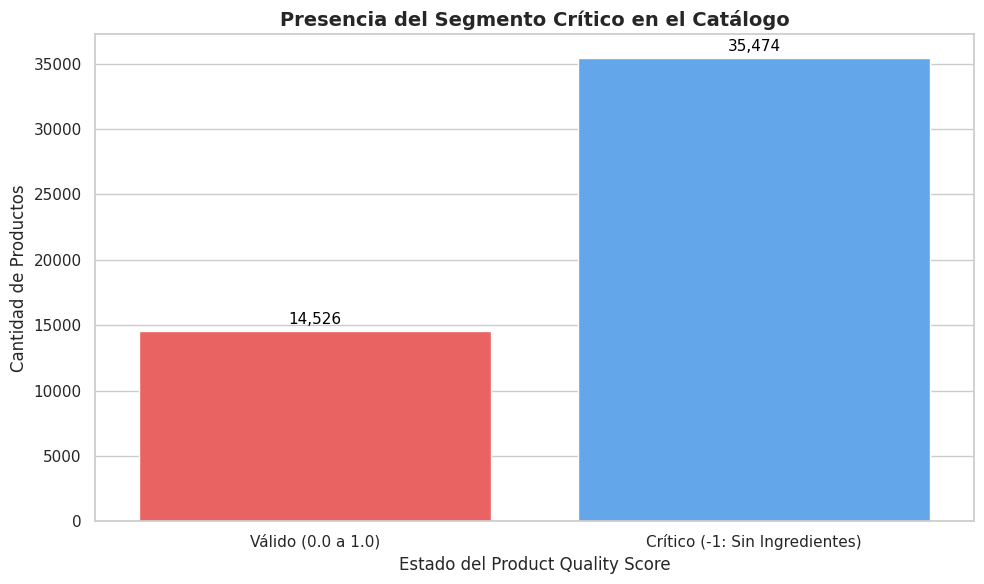

In [65]:
# 1. Creacion de una columna temporal, para agrupar los scores 
# Se marca si el score es -1 (Sin Datos) o si es un score válido entre 0 y 1
df['score_status'] = df['product_quality_score'].apply(
    lambda x: "Crítico (-1: Sin Ingredientes)" if x == -1 else "Válido (0.0 a 1.0)"
)

# 2. Configuración de la gráfica simple
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Graficamos el conteo de cada estado
sns.countplot(
    data=df,
    x="score_status",
    hue="score_status",
    palette=["#ff4d4d", "#4da6ff"],  # Rojo para el error, azul para los válidos
    legend=False,
)

# 4. Configuramos títulos y etiquetas claras
plt.title("Presencia del Segmento Crítico en el Catálogo", fontsize=14, fontweight="bold")
plt.xlabel("Estado del Product Quality Score")
plt.ylabel("Cantidad de Productos")

# 5. Mostramos los valores exactos encima de cada barra para que quede constancia matemática
ax = plt.gca()
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='baseline', 
        fontsize=11, color='black', 
        xytext=(0, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# 6. Limpieza de la columna temporal para no ensuciar tu dataset original
df = df.drop(columns=["score_status"])


In [66]:
# Diferenciar valores
df_valid = df[df['product_quality_score']>0]

/tmp/ipykernel_7870/4265634279.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  sns.barplot(


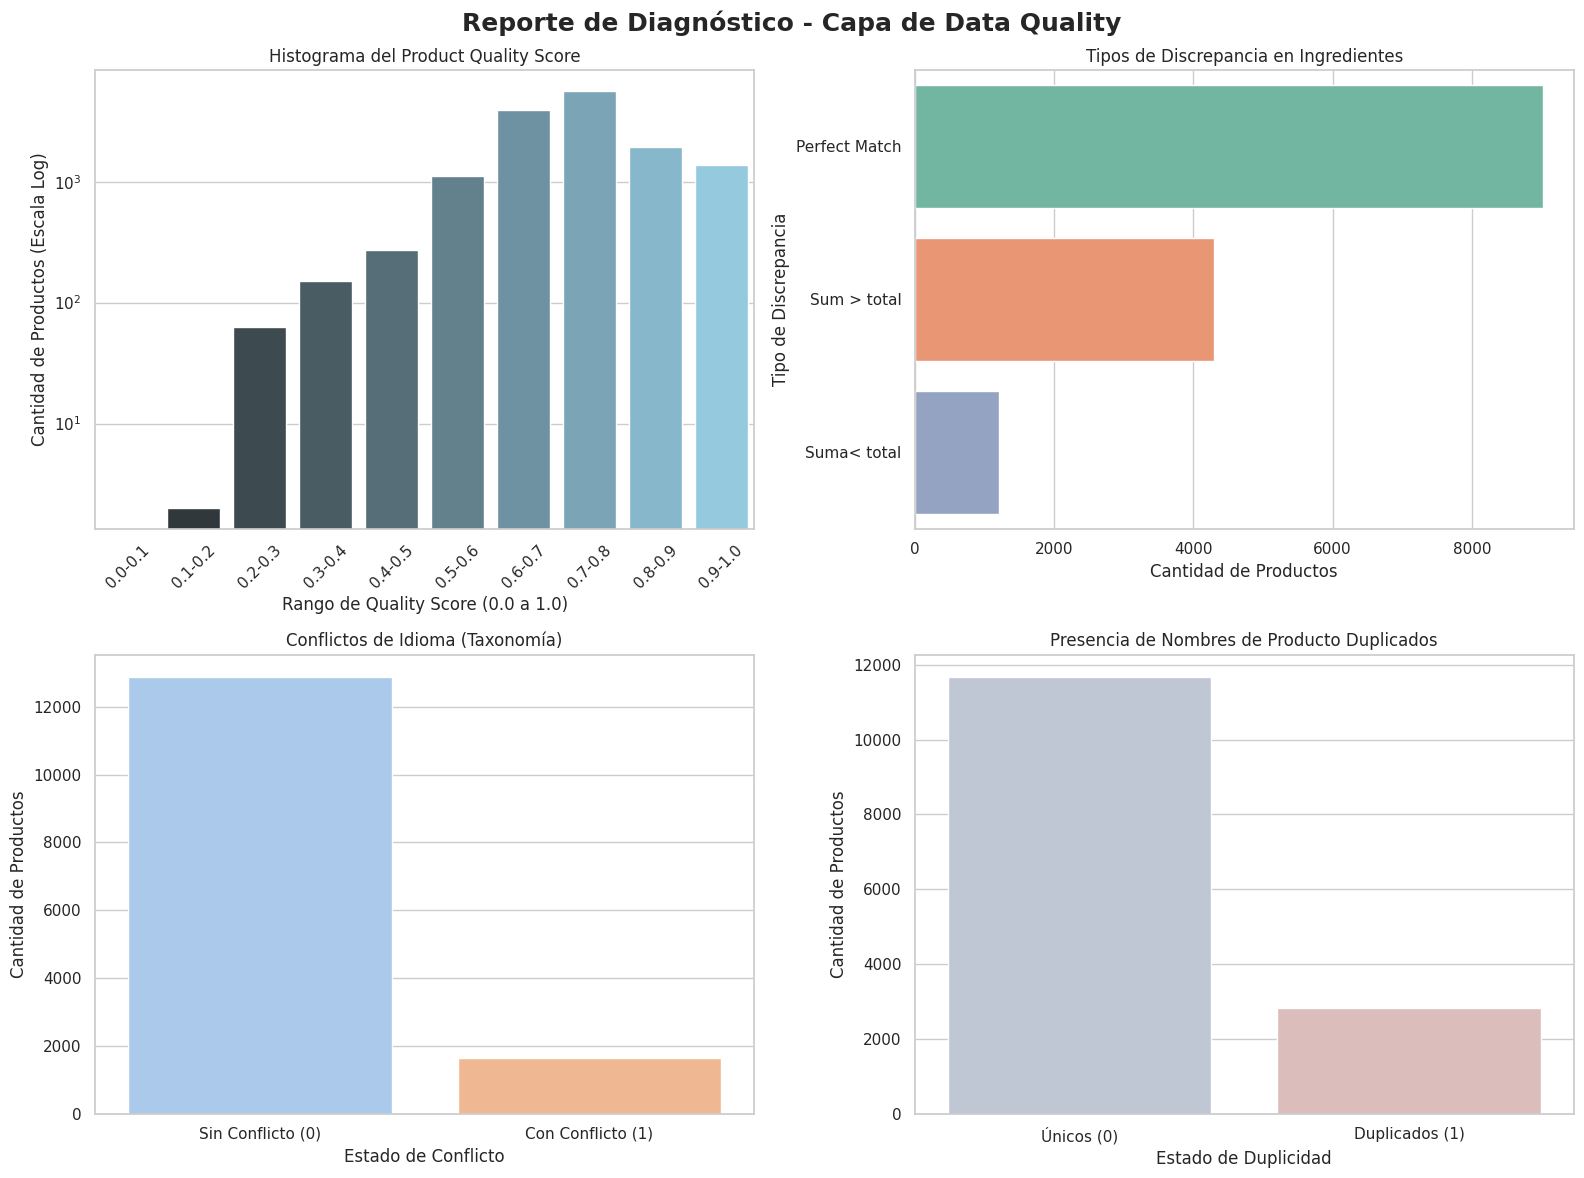

In [67]:
# --- PREPARACIÓN PARA LA GRÁFICA 1 (Rangos del Histograma) ---
bins = np.linspace(0, 1.0, 11)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(10)]
df_valid["quality_range"] = pd.cut(
    df_valid["product_quality_score"], bins=bins, labels=labels, include_lowest=True
)
counts_by_range = (
    df_valid["quality_range"].value_counts().reindex(labels).reset_index()
)
counts_by_range.columns = ["Rango", "Cantidad"]

# --- CONFIGURACIÓN DEL LIENZO (2x2) ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Reporte de Diagnóstico - Capa de Data Quality",
    fontsize=18,
    fontweight="bold",
)

# 1. CUADRANTE TOP-LEFT: Histograma por Rangos (Logarítmico)
sns.barplot(
    data=counts_by_range,
    x="Rango",
    y="Cantidad",
    ax=axes[0, 0],
    color="skyblue",
    hue="Rango",
    legend=False,
)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Histograma del Product Quality Score")
axes[0, 0].set_xlabel("Rango de Quality Score (0.0 a 1.0)")
axes[0, 0].set_ylabel("Cantidad de Productos (Escala Log)")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. CUADRANTE TOP-RIGHT: Discrepancias de Ingredientes
sns.countplot(
    data=df_valid,
    y="ingredients_discrepancy_type",
    ax=axes[0, 1],
    hue="ingredients_discrepancy_type",
    palette="Set2",
    legend=False,
    order=df["ingredients_discrepancy_type"].value_counts().index,
)
axes[0, 1].set_title("Tipos de Discrepancia en Ingredientes")
axes[0, 1].set_xlabel("Cantidad de Productos")
axes[0, 1].set_ylabel("Tipo de Discrepancia")

# 3. CUADRANTE BOTTOM-LEFT: Conflictos de Idioma
sns.countplot(
    data=df_valid,
    x="has_lang_conflict",
    ax=axes[1, 0],
    hue="has_lang_conflict",
    palette="pastel",
    legend=False,
)
axes[1, 0].set_title("Conflictos de Idioma (Taxonomía)")
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["Sin Conflicto (0)", "Con Conflicto (1)"])
axes[1, 0].set_xlabel("Estado de Conflicto")
axes[1, 0].set_ylabel("Cantidad de Productos")

# 4. CUADRANTE BOTTOM-RIGHT: Nombres Duplicados
sns.countplot(
    data=df_valid,
    x="is_duplicate_product_name",
    ax=axes[1, 1],
    hue="is_duplicate_product_name",
    palette="vlag",
    legend=False,
)
axes[1, 1].set_title("Presencia de Nombres de Producto Duplicados")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Únicos (0)", "Duplicados (1)"])
axes[1, 1].set_xlabel("Estado de Duplicidad")
axes[1, 1].set_ylabel("Cantidad de Productos")

# --- CIERRE Y LIMPIEZA ---
plt.tight_layout()
plt.show()

# Eliminamos la columna temporal para mantener intacto tu dataset original
df_valid = df_valid.drop(columns=["quality_range"])



In [ ]:
### Guardando data quality dataset

In [ ]:
df.to_csv("data_quality_no_filter.csv")

In [70]:
df_quality = df[df['product_quality_score']>0]
df_quality.to_csv("data_quality_filter.csv")

In [71]:
df_quality = df_quality.map(
    lambda x: json.dumps(list(x)) if isinstance(x, set)
    else json.dumps(x) if isinstance(x, (list, dict))
    else x
)
df_quality.to_sql("metrics_quality_products", conn, if_exists="replace", index=False)

14524

In [72]:
pd.read_sql("SELECT * FROM metrics_quality_products", conn).head()

,_id,code,rev,update_key,brands,product_name,product_type,countries,countries_tags,countries_hierarchy,...,missing_country_flag,missing_category_flag,missing_both_taxonomy_flag,country_languages,category_languages,countries_mixl,categories_mixl,has_lang_conflict,taxonomy_score,product_quality_score
0,8410757001090,8410757001090,34,key_1743168287,S'nonas,Crema Manos,beauty,"Morocco, United States, en:france","[""en:france"", ""en:morocco"", ""en:united-states""]","[""en:france"", ""en:morocco"", ""en:united-states""]",...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.985417
1,6281006408647,6281006408647,30,brands,"Unilever,Vaseline",,beauty,"Germany, Morocco, en:saudi-arabia","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]",...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.650000
2,80466468,80466468,68,brands,"unilever, dove",DOVE Déodorant Femme Anti-Transpirant Stick Or...,beauty,"France, Libya, Morocco, Saudi Arabia, Spain, e...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...",...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,1.000000
3,3337875598996,3337875598996,33,brands,CeraVe,moisturising cream,beauty,"France,Morocco,Romania","[""en:france"", ""en:morocco"", ""en:romania""]","[""en:france"", ""en:morocco"", ""en:romania""]",...,0,0,0,"[""en""]","[""fr""]",0,0,1,0.666667,0.775000
4,3574669909594,3574669909594,35,key_1743168287,Johnson’s baby,,beauty,"Algeria, Morocco, en:ukraine","[""en:algeria"", ""en:morocco"", ""en:ukraine""]","[""en:algeria"", ""en:morocco"", ""en:ukraine""]",...,0,1,0,"[""en""]",[],0,0,0,1.000000,1.000000


### Creación del dataset limpio

In [75]:
df_quality.columns

Index(['_id', 'code', 'rev', 'update_key', 'brands', 'product_name',
       'product_type', 'countries', 'countries_tags', 'countries_hierarchy',
       'categories_hierarchy', 'categories', 'product_quantity',
       'product_quantity_unit', 'quantity', 'ingredients_n',
       'known_ingredients_n', 'unknown_ingredients_n', 'completeness',
       'scans_n', 'unique_scans_n', 'popularity_tags', 'created_t',
       'last_modified_t', 'last_updated_t', 'creator', 'last_editor',
       'last_modified_by', 'data_quality_tags', 'page', 'batch_id',
       'dtinserted', 'canonical_countries', 'canonical_categories',
       'completeness_ratio', 'compl_critical_ratio', 'is_duplicate_code',
       'is_duplicate_product_name', 'ingredients_match',
       'ingredients_discrepancy_type', 'unknown_ingredients_ratio',
       'ingredients_quality_score', 'countries_count', 'categories_count',
       'missing_country_flag', 'missing_category_flag',
       'missing_both_taxonomy_flag', 'country_languag

In [76]:
columns_to_keep = [
"code",
"product_name",
"product_type",
"brands",
"canonical_categories",
"canonical_countries",
"ingredients_n",
"known_ingredients_n",
"unknown_ingredients_n",
"completeness",
"scans_n",
"unique_scans_n",
"creator",
'completeness_ratio', 'compl_critical_ratio',
'is_duplicate_product_name', 'ingredients_match',
'unknown_ingredients_ratio',
'ingredients_quality_score', 'countries_count', 'categories_count',
'missing_country_flag', 'missing_category_flag',
'missing_both_taxonomy_flag', 'country_languages', 'category_languages',
'countries_mixl', 'categories_mixl', 'has_lang_conflict',
'taxonomy_score', 'product_quality_score'
]

In [77]:
clean_df = df_quality[columns_to_keep]

In [ ]:
clean_df["ingredients_n"] = (
    pd.to_numeric(clean_df["ingredients_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)
clean_df["known_ingredients_n"] = (
    pd.to_numeric(clean_df["known_ingredients_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)
clean_df["unknown_ingredients_n"] = (
    pd.to_numeric(clean_df["unknown_ingredients_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)


In [78]:
clean_df.head(5)

,code,product_name,product_type,brands,canonical_categories,canonical_countries,ingredients_n,known_ingredients_n,unknown_ingredients_n,completeness,...,missing_country_flag,missing_category_flag,missing_both_taxonomy_flag,country_languages,category_languages,countries_mixl,categories_mixl,has_lang_conflict,taxonomy_score,product_quality_score
0,8410757001090,Crema Manos,beauty,S'nonas,"[""en:Creams"", ""en:Non-food-products"", ""en:Open...","[""en:france"", ""en:morocco"", ""en:united-states""]",24,23.0,1,0.5625,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.985417
1,6281006408647,,beauty,"Unilever,Vaseline","[""en:incorrect-product-type"", ""en:Non-food-pro...","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]",1,0.0,1,0.4625,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.650000
2,80466468,DOVE Déodorant Femme Anti-Transpirant Stick Or...,beauty,"unilever, dove","[""en:D\u00e9odorants anti-transpirants"", ""en:o...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...",19,19.0,0,0.6875,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,1.000000
3,3337875598996,moisturising cream,beauty,CeraVe,"[""fr:baume hydratant""]","[""en:france"", ""en:morocco"", ""en:romania""]",28,12.0,16,0.8875,...,0,0,0,"[""en""]","[""fr""]",0,0,1,0.666667,0.775000
4,3574669909594,,beauty,Johnson’s baby,[],"[""en:algeria"", ""en:morocco"", ""en:ukraine""]",3,3.0,0,0.2625,...,0,1,0,"[""en""]",[],0,0,0,1.000000,1.000000


In [79]:
clean_df.to_csv("clean_data_products.csv")
clean_df = df_quality = clean_df.map(
    lambda x: json.dumps(list(x)) if isinstance(x, set)
    else json.dumps(x) if isinstance(x, (list, dict))
    else x
)
clean_df.to_sql("clean_data", conn, if_exists="replace", index=False)

14524

In [80]:
clean_df

,code,product_name,product_type,brands,canonical_categories,canonical_countries,ingredients_n,known_ingredients_n,unknown_ingredients_n,completeness,...,missing_country_flag,missing_category_flag,missing_both_taxonomy_flag,country_languages,category_languages,countries_mixl,categories_mixl,has_lang_conflict,taxonomy_score,product_quality_score
0,8410757001090,Crema Manos,beauty,S'nonas,"[""en:Creams"", ""en:Non-food-products"", ""en:Open...","[""en:france"", ""en:morocco"", ""en:united-states""]",24,23.0,1,0.5625,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.985417
1,6281006408647,,beauty,"Unilever,Vaseline","[""en:incorrect-product-type"", ""en:Non-food-pro...","[""en:germany"", ""en:morocco"", ""en:saudi-arabia""]",1,0.0,1,0.4625,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.650000
2,80466468,DOVE Déodorant Femme Anti-Transpirant Stick Or...,beauty,"unilever, dove","[""en:D\u00e9odorants anti-transpirants"", ""en:o...","[""en:algeria"", ""en:france"", ""en:libya"", ""en:mo...",19,19.0,0,0.6875,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,1.000000
3,3337875598996,moisturising cream,beauty,CeraVe,"[""fr:baume hydratant""]","[""en:france"", ""en:morocco"", ""en:romania""]",28,12.0,16,0.8875,...,0,0,0,"[""en""]","[""fr""]",0,0,1,0.666667,0.775000
4,3574669909594,,beauty,Johnson’s baby,[],"[""en:algeria"", ""en:morocco"", ""en:ukraine""]",3,3.0,0,0.2625,...,0,1,0,"[""en""]",[],0,0,0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49965,3574661711485,Extra Gentle Coconut Shower and Bath Cream,beauty,Le Petit Marseilliais,"[""en:body wash""]","[""en:united-states""]",16.0,15.0,1.0,0.5750,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.978125
49966,8720181334030,duschdas Magnolie,beauty,"Unilever,duschdas","[""en:hygiene"", ""en:showers-and-baths"", ""en:sho...","[""en:germany""]",20.0,18.0,2.0,0.5875,...,0,0,0,"[""en""]","[""en""]",0,0,0,1.000000,0.965000
49968,4335619129931,NaN,beauty,Cien MEN,[],"[""en:bulgaria""]",16.0,14.0,2.0,0.3500,...,0,1,0,"[""en""]",[],0,0,0,1.000000,0.684821
49969,8720181688454,Coral MAGIC WASH QUICK & CARE Universal Clean,beauty,Coral Unilever,"[""de:Waschmittel""]","[""en:germany""]",13.0,5.0,8.0,0.6875,...,0,0,0,"[""en""]","[""de""]",0,0,1,0.666667,0.759615
